<a href="https://colab.research.google.com/github/1021114Carlos/MIT_MM_Finance/blob/Finance-shop/Courses/Derivative_Markets/volatility_and_other_options_pricing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [1]:
from IPython.display import display, Math
import math
from scipy.stats import norm
import matplotlib.pyplot as plt

(Q1)

In [ ]:
# Find value/price of European put using BSM
futures_current_price = 70
sigma = (21.28/100)
rfr = (6.37/100)  # continuous compounding
t = (5/12)
k_put = 65

print("Black Scholes Merton model for put price: ")
print("\n")
display(Math(r"p = e^{-rt}[KN(-d_2) - F_0N(-d_1)]"))
print("\nWhere\n")
display(Math(r"d_1 = \frac{ln(\frac{f_0}{k}) + (\frac{\sigma^2}{2})T}{\sigma\sqrt(T)}, \  \ d_2 = d_1 - \sigma\sqrt(t)"))




Black Scholes Merton model for put price: 




<IPython.core.display.Math object>


Where



<IPython.core.display.Math object>

In [ ]:
d1 = (math.log(futures_current_price/k_put) + ((sigma**2)/2)*t)/(sigma*math.sqrt(t))
d2 = d1 - (sigma*math.sqrt(t))

# Calculate N(-d1) a& N(-d2)
n_d1 = norm.cdf(-d1)
n_d2 = norm.cdf(-d2)

# bsm model
euro_put_price = math.e**(-rfr*t)*(k_put*n_d2 - futures_current_price*n_d1)
print(euro_put_price)



1.6751048524805392


(Q2 A)

In [ ]:
print("Building up/down multipliers.\n")
u = display(Math(r"u = e^{\sigma\sqrt{\Delta(t)}}"))
d = display(Math(r"u = e^{-\sigma\sqrt{\Delta(t)}} = \frac{1}{u}"))

print("\nRisk-neutral probability p for a futures tree.\n")
# Under risk-neutral probability, the futures price is martingale.
martingale = display(Math(r"E^q[F_{t + \Delta(t)} \ | \ F_t] = F_t"))
print("After derivation of martingale\n")
risk_neutral = display(Math(r"p = \frac{1 - d}{u-d}"))

print("\nEuropean call payoff at t\n")

c_t = display(Math(r"C_t = max(F_t - K, 0)"))

print("\nDiscount back one step (backward induction.)\n")
df = display(Math(r"df = e^{-r\Delta(t)}"))

print("\nValue at the up node (time delta t)\n")
c_u = display(Math(r"e^{-r\Delta(t)}[pC_{uu} + (1 - p)C_{ud}]"))

print("\nValue at the up node (time delta t)\n")
c_d = display(Math(r"e^{-r\Delta(t)}[pC_{ud} + (1 - p)C_{dd}]"))

print("\nDiscount back to today t=0\n")
c0 = display(Math(r"e^{-r\Delta(t)}[pC_u + (1 - p)C_d]"))


Building up/down multipliers.



<IPython.core.display.Math object>

<IPython.core.display.Math object>


Risk-neutral probability p for a futures tree.



<IPython.core.display.Math object>

...

<IPython.core.display.Math object>


Value at the up node (time delta t)



<IPython.core.display.Math object>


Discount back to today t=0



<IPython.core.display.Math object>

In [ ]:
import math

f0 = 60
K = 60
sigma = 32.56/100
r = 8.37/100
T = 6/12
dt = T/2

# Multipliers
u = math.exp(sigma * math.sqrt(dt))
d = 1 / u

p = (1 - d) / (u - d)

# Futures tree (2 steps)
fu = f0*u
fd = f0*d
Fuu = f0 * u**2
Fud = f0              # because u*d = 1
Fdd = f0 * d**2

# Payoffs at maturity
Cuu = max(Fuu - K, 0)
Cud = max(Fud - K, 0)
Cdd = max(Fdd - K, 0)

df = math.exp(-r * dt)

# Backward induction
Cu = df * (p*Cuu + (1-p)*Cud)
Cd = df * (p*Cud + (1-p)*Cdd)
C0 = df * (p*Cu  + (1-p)*Cd)
print(f"Multipliers u = {u:.6f}, d = {d:.6f}, p = {p:6f}\n")
print(f"\nValue of a 6-month European call on the Futures. ${C0:.4f}")


Multipliers u = 1.176801, d = 0.849761, p = 0.459390


Value of a 6-month European call on the Futures. $4.6735


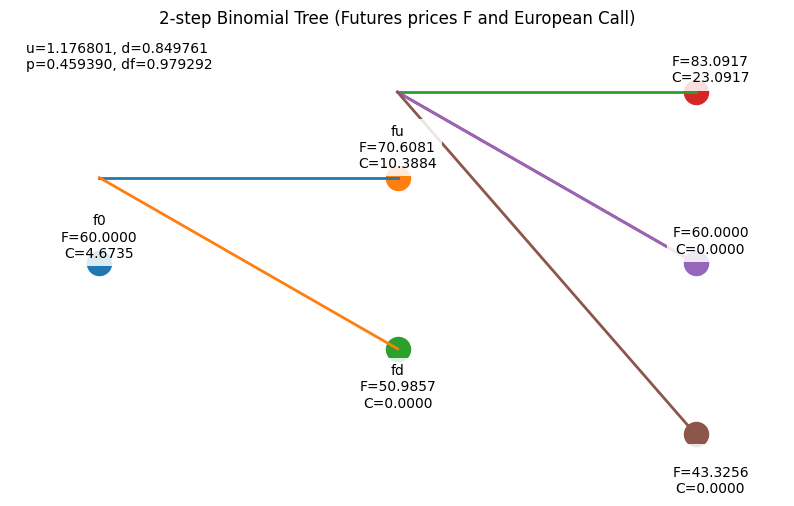

In [ ]:
# Visualization

nodes = {"f0": (0, 0, f"f0\nF={f0:.4f}\nC={C0:.4f}"),
         "fu": (1,1, f"fu\nF={fu:.4f}\nC={Cu:.4f}"),
         "fd": (1,-1, f"fd\nF={fd:.4f}\nC={Cd:.4f}"),
         "fuu": (2, 2, f"\nF={Fuu:.4f}\nC={Cuu:.4f}"),
         "fud": (2, 0, f"\nF={Fud:.4f}\nC={Cud:.4f}"),
         "fdd":  (2, -2, f"\nF={Fdd:.4f}\nC={Cdd:.4f}"),
         }

edges = [("f0", "fu"), ("f0", "fd"), ("fu", "fuu"),
         ("fu", "fud"), ("fd", "fud"), ("fd", "fdd")
         ]

# Offsetting labels so labels don't sit on nodes

offset = {"f0": (0.00, 0.30), "fu": (0.00, 0.35),
          "fd": (0.00, -0.45), "fuu": (0.05, 0.35),
          "fud": (0.05, 0.35), "fdd": (0.05, -0.45)
          }

plt.figure(figsize=(10,6))
ax = plt.gca()

# Draw edges
for a, b in edges:
  x1, y1, _ = nodes[a]
  x2, y2, _ = nodes[b]
  ax.plot([x1, x2], [x2, y2], linewidth=2)

# nodes + labels
for name, (x, y, label) in nodes.items():
  ax.scatter([x], [y], s=300)
  dx, dy = offset[name]
  ax.text(x + dx, y + dy, label, ha="center", va="center",
          fontsize=10,
          bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
          )

# info box
info = f"u={u:.6f}, d={d:.6f}\np={p:.6f}, df={df:.6f}"
ax.text(0.02, 0.98, info, transform=ax.transAxes, va="top",
        bbox=dict(facecolor="white", alpha=0.85,
                  edgecolor="none")
        )

ax.set_title("2-step Binomial Tree (Futures prices F and European Call)")
ax.set_xlim(-0.3, 2.3)
ax.set_ylim(-2.7, 2.7)
ax.axis("off")
plt.show()




(C)

In [ ]:
# (B) is a reasoning question.
print("European put payoff at maturity t\n")
p_payoff = display(Math(r"max(K - F_t, 0)"))
print("\n")
Puu = max(K - Fuu, 0)
Pud = max(K - Fud, 0)
Pdd = max(K - Fdd, 0)
print(Puu, Pud, Pdd,"\n")

# for options on futures, the put-call parity
print("Put-Call parity\n")
p_c_parity = display(Math(r"c + Ke^{-rT} = p + Fe^{-rT}"))

European put payoff at maturity t



<IPython.core.display.Math object>



0 0 16.674361964471785 

Put-Call parity



<IPython.core.display.Math object>

(Q3)

In [16]:
print("Finding Inplied volatilities (IV) to match prices")
# Black-Scholes with dividend yield q
call_price = display(Math(r"C(\sigma) = S_0e^{-qT}N(d_1) - Ke^{-rT}N(d_2)"))
print("\n")
put_price = display(Math(r"P(\sigma) = Ke^{-qT}N(d_2) - S_0e^{-rT}N(-d_1)"))
print("\nWhere\n")
d1 = display(Math(r"\frac{ln(\frac{S_0}{K}) + (r - q + \frac{1}{2}\sigma^2)T}{\sigma\sqrt(T)}"))
print("\n")
d2 = display(Math(r"d1 - \sigma\sqrt(T)"))





<IPython.core.display.Math object>

<IPython.core.display.Math object>


Where



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [27]:
def bs_call_price(S, K, r, q, T, sigma):
  d1 = (math.log(S/K) + (r - q + 0.5*sigma**2)*T)/(sigma*math.sqrt(T))
  d2 = d1 - sigma*math.sqrt(T)
  return S*math.exp(-q*T)*norm.cdf(d1) - K*math.exp(-r*T)*norm.cdf(d2)

def bs_put_price(S, K, r, q, T, sigma):
  d1 = (math.log(S/K) + (r - q + 0.5*sigma**2)*T)/(sigma*math.sqrt(T))
  d2 = d1 - sigma*math.sqrt(T)
  return K*math.exp(-r*T)*norm.cdf(-d2) - S*math.exp(-q*T)*norm.cdf(-d1)


In [37]:
# Implied Volatility (IV) using biseciton search
def iv(price_mkt, S, K, r, q, T, option_type,
       tol=1e-8, max_iter=10_000):
  sigma_low = 1e-6
  sigma_high = 5.0

  for _ in range(max_iter):
    sigma_mid = 0.5*(sigma_low + sigma_high)
    if option_type == "call":
      price_mid = bs_call_price(S, K, r, q, T, sigma_mid)
    else:
      price_mid = bs_put_price(S, K, r, q, T, sigma_mid)

    if abs(price_mid - price_mkt) < tol:
      return sigma_mid

    if price_mid > price_mkt:
      sigma_high = sigma_mid
    else:
      sigma_low = sigma_mid

  return sigma_mid



In [40]:
# Market inputs
S0 = 4670
r = 0.0059
q = 0.0163

# Actual/365 and from 11/4/21 to 11/18/22
days = 379
T = days/365

# option data (last prices)
strikes = [4600,4625, 4650, 4675, 4700, 4725]
call_prices = [382.60, 365.98, 321.40, 334.81, 294.80, 266.17]
put_prices = [344.03, 348.29, 387.59, 366.81, 395.38, 425.23]

print("Strike | Call IV (%) | Put IV (%)\n")

for K, C_mkt, P_mkt in zip(strikes, call_prices, put_prices):
  iv_call = iv(C_mkt, S0, K, r, q, T, "call")
  iv_put = iv(P_mkt, S0, K, r, q, T, "put")
  print(f"{K:>6} | {100*iv_call:>10.4f} | {100*iv_put:>9.4f}")

Strike | Call IV (%) | Put IV (%)

  4600 |    20.0423 |   19.0250
  4625 |    19.7663 |   18.5386
  4650 |    17.9767 |   19.9206
  4675 |    19.2863 |   18.0630
  4700 |    17.7174 |   18.8376
  4725 |    16.7427 |   19.6661


(B)

In [46]:
# Estimate option values with K=$4675 when volatility increases and decreseas Times the IV
def N(x):
    return 0.5*(1+math.erf(x/math.sqrt(2)))

def bs_call(S,K,r,q,T,sigma):
    d1=(math.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*math.sqrt(T))
    d2=d1-sigma*math.sqrt(T)
    return S*math.exp(-q*T)*N(d1)-K*math.exp(-r*T)*N(d2)

def bs_put(S,K,r,q,T,sigma):
    d1=(math.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*math.sqrt(T))
    d2=d1-sigma*math.sqrt(T)
    return K*math.exp(-r*T)*N(-d2)-S*math.exp(-q*T)*N(-d1)

S0=4670
K=4675
r=0.0059
q=0.0163
T=379/365


sigma_call_iv=0.192863
sigma_put_iv=0.18063

for label,sig in [("Call 0.8×IV: $",0.8*sigma_call_iv),
                  ("Call 1.2×IV: $",1.2*sigma_call_iv)]:
    print(label, round(bs_call_price(S0,K,r,q,T,sig),4))

for label,sig in [("Put 0.8×IV: $",0.8*sigma_put_iv),
                  ("Put 1.2×IV: $",1.2*sigma_put_iv)]:
    print(label, round(bs_put_price(S0,K,r,q,T,sig),4))

Call 0.8×IV: $ 262.8298
Call 1.2×IV: $ 406.7051
Put 0.8×IV: $ 299.3854
Put 1.2×IV: $ 434.18
